In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

# Load datasets
players    = pd.read_csv('players.csv')
valuations = pd.read_csv('player_valuations.csv')
fbref      = pd.read_csv('players_data-2024_2025.csv')

print('Players:', players.shape)
print('Valuations:', valuations.shape)
print('FBRef:', fbref.shape)

Players: (50149, 26)
Valuations: (507815, 6)
FBRef: (2854, 267)


In [2]:
# Filter to Big 5 leagues, 2025/26 season
big5 = ['GB1', 'L1', 'IT1', 'ES1', 'FR1']
val_2526 = valuations[
    (valuations['date'] >= '2025-07-01') &
    (valuations['player_club_domestic_competition_id'].isin(big5))
].copy()

# Keep most recent valuation per player
val_latest = val_2526.sort_values('date').groupby('player_id').last().reset_index()

# Merge with player names
val_named = pd.merge(val_latest, players[['player_id', 'name']], on='player_id')

print('Players with 2025/26 Big 5 valuations:', val_named.shape[0])
print(val_named[['name', 'market_value_in_eur', 'current_club_name']].head(5).to_string())

Players with 2025/26 Big 5 valuations: 1962
            name  market_value_in_eur       current_club_name
0   James Milner               750000  Brighton & Hove Albion
1  Jonas Hofmann              2000000     Bayer 04 Leverkusen
2    Daley Blind              1400000               Girona FC
3   Ashley Young               400000            Ipswich Town
4    Raúl Albiol               800000      Pisa Sporting Club


In [3]:
# Function to clean club names for matching
def clean_club(name):
    if pd.isna(name): return ''
    name = str(name).lower().strip()
    for suffix in [' fc', ' cf', ' cfc', ' afc', ' sc', ' ac', ' united',
                   ' city', ' sporting', ' s.p.a.', ' s.a.', ' 1899']:
        name = name.replace(suffix, '')
    return name.strip()

# Clean names and clubs in both datasets
val_named['name_clean'] = val_named['name'].str.strip().str.lower()
val_named['club_clean'] = val_named['current_club_name'].apply(clean_club)
fbref['name_clean'] = fbref['Player'].str.strip().str.lower()
fbref['club_clean'] = fbref['Squad'].apply(clean_club)

# Primary merge — name + club
merged_strict = pd.merge(fbref,
    val_named[['name_clean', 'club_clean', 'market_value_in_eur']],
    on=['name_clean', 'club_clean'], how='inner').copy()
print(f'Strict merge (name + club): {merged_strict.shape[0]} players')

# Secondary merge — unique names only for unmatched players
matched = set(zip(merged_strict['name_clean'], merged_strict['club_clean']))
fbref_rem = fbref[~fbref.apply(lambda r: (r['name_clean'], r['club_clean']) in matched, axis=1)]
val_rem = val_named[~val_named.apply(lambda r: (r['name_clean'], r['club_clean']) in matched, axis=1)]

name_fc = fbref_rem['name_clean'].value_counts()
name_vc = val_rem['name_clean'].value_counts()
unique_names = set(name_fc[name_fc==1].index) & set(name_vc[name_vc==1].index)

merged_loose = pd.merge(
    fbref_rem[fbref_rem['name_clean'].isin(unique_names)],
    val_rem[val_rem['name_clean'].isin(unique_names)][['name_clean', 'market_value_in_eur']],
    on='name_clean', how='inner').copy()
print(f'Additional unique name matches: {merged_loose.shape[0]} players')

# Combine both
merged = pd.concat([merged_strict, merged_loose], ignore_index=True)
merged = merged[merged['market_value_in_eur'] > 0].copy()
print(f'Total matched: {merged.shape[0]} players')

Strict merge (name + club): 300 players
Additional unique name matches: 991 players
Total matched: 1291 players


In [4]:
# Convert relevant columns to numeric
cols = ['Gls','Ast','npxG','xAG','SCA','PrgC','G-xG','Min','Age','90s',
        'PPM','SoT%','Won%','npxG/Sh']
for col in cols:
    if col in merged.columns:
        merged[col] = pd.to_numeric(merged[col], errors='coerce')

# Filter to pure forwards, 900+ minutes, age 21+
merged['pos_clean'] = merged['Pos'].str.split(',').str[0].str.strip()
fw = merged[
    (merged['pos_clean'] == 'FW') &
    (merged['Min'] >= 900) &
    (merged['Age'] >= 21) &
    (merged['market_value_in_eur'] > 0)
].dropna(subset=cols+['market_value_in_eur']).copy()

# Calculate per-90 metrics
fw['gls_p90']  = fw['Gls']      / fw['90s']
fw['npxg_p90'] = fw['npxG']     / fw['90s']
fw['ast_p90']  = fw['Ast']      / fw['90s']
fw['xag_p90']  = fw['xAG']      / fw['90s']
fw['sca_p90']  = fw['SCA']      / fw['90s']
fw['prgc_p90'] = fw['PrgC']     / fw['90s']
fw['gxg_p90']  = fw['G-xG']     / fw['90s']
fw['npxg_sh']  = fw['npxG/Sh']
fw['age_sq']   = fw['Age'] ** 2
fw['ln_value'] = np.log(fw['market_value_in_eur'])

# Big club dummy
big_clubs = [
    'real madrid','manchester city','arsenal','liverpool','chelsea',
    'manchester utd','barcelona','paris s-g','bayern munich','inter',
    'juventus','ac milan','atlético madrid','dortmund','napoli',
    'tottenham','aston villa','newcastle utd','bayer leverkusen','rb leipzig'
]
fw['big_club'] = fw['Squad'].str.lower().str.strip().isin(big_clubs).astype(int)

print(f'Forwards dataset: {fw.shape[0]} players')
print(f'Age range: {fw["Age"].min():.0f} to {fw["Age"].max():.0f}')
print(f'Value range: €{fw["market_value_in_eur"].min()/1e6:.1f}m to €{fw["market_value_in_eur"].max()/1e6:.0f}m')

Forwards dataset: 167 players
Age range: 21 to 37
Value range: €0.8m to €200m


In [5]:
formula = ('ln_value ~ Age + age_sq + big_club + PPM + '
           'gls_p90 + npxg_p90 + gxg_p90 + ast_p90 + '
           'xag_p90 + sca_p90 + prgc_p90 + Q("SoT%") + '
           'Q("Won%") + npxg_sh')

model = smf.ols(formula=formula, data=fw).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               ln_value   R-squared:                       0.687
Model:                            OLS   Adj. R-squared:                  0.658
Method:                 Least Squares   F-statistic:                     23.78
Date:                Sun, 19 Jul 2026   Prob (F-statistic):           1.94e-31
Time:                        19:43:06   Log-Likelihood:                -173.76
No. Observations:                 167   AIC:                             377.5
Df Residuals:                     152   BIC:                             424.3
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.8191      2.929      3.693      0.0

In [6]:
fw['predicted_ln']    = model.fittedvalues
fw['residual']        = fw['ln_value'] - fw['predicted_ln']
fw['predicted_value'] = np.exp(fw['predicted_ln'])

# Check key players
for name in ['Erling Haaland', 'Gonçalo Ramos', 'Lautaro Martínez',
             'Mohamed Salah', 'Kylian Mbappé']:
    row = fw[fw['Player'] == name]
    if len(row) > 0:
        r = row.iloc[0]
        print(f'{name}: actual €{r["market_value_in_eur"]/1e6:.0f}m, '
              f'predicted €{r["predicted_value"]/1e6:.0f}m')

Erling Haaland: actual €200m, predicted €58m
Gonçalo Ramos: actual €35m, predicted €127m
Lautaro Martínez: actual €85m, predicted €25m
Mohamed Salah: actual €30m, predicted €31m


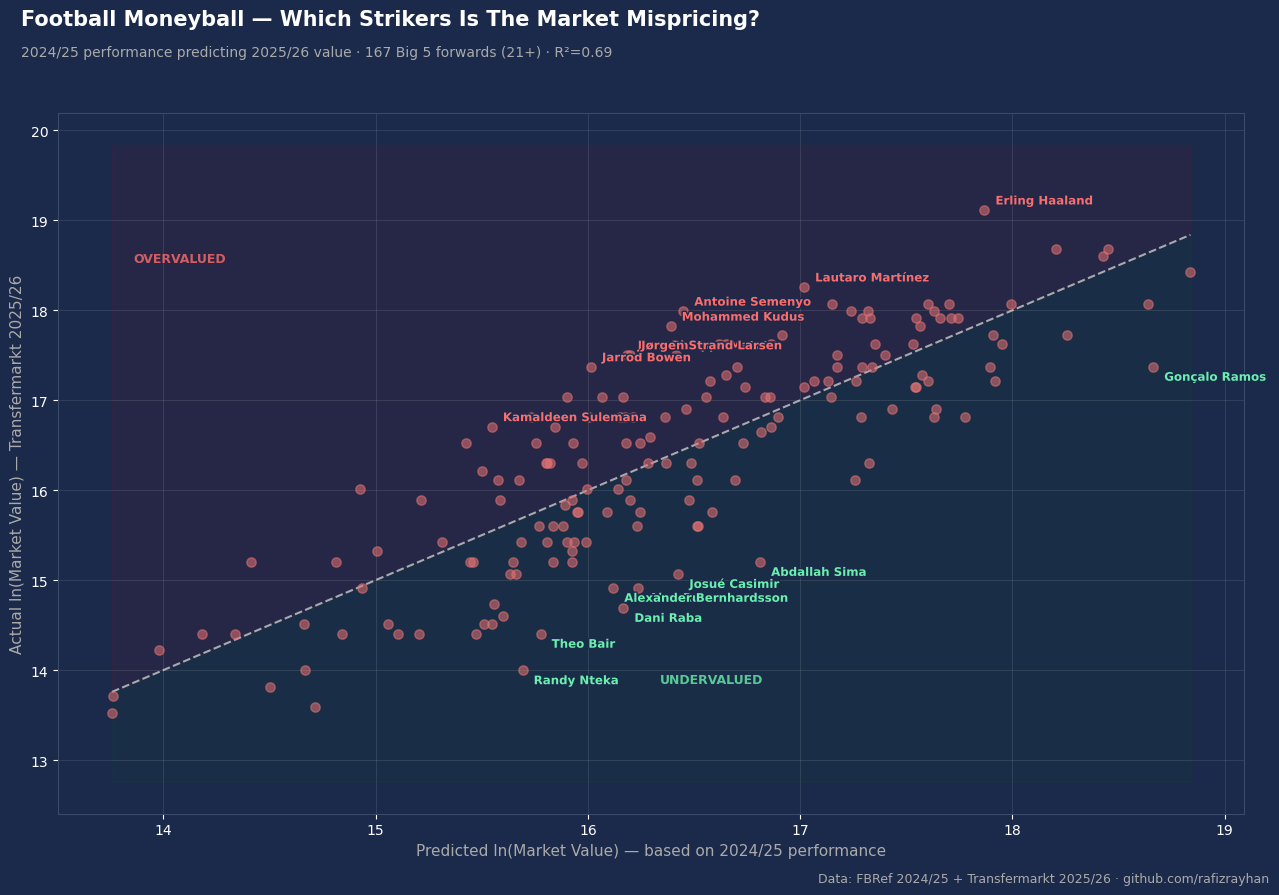

In [7]:
fig, ax = plt.subplots(figsize=(13, 9))
fig.patch.set_facecolor('#1B2A4A')
ax.set_facecolor('#1B2A4A')

ax.scatter(fw['predicted_ln'], fw['ln_value'],
           c='#E57373', alpha=0.55, s=45, zorder=3)

min_val = fw['predicted_ln'].min()
max_val = fw['predicted_ln'].max()
ax.plot([min_val, max_val], [min_val, max_val],
        color='white', linewidth=1.5, linestyle='--', alpha=0.6, zorder=2)

top_over  = fw.nlargest(8, 'residual')
top_under = fw.nsmallest(8, 'residual')

for _, row in top_over.iterrows():
    ax.annotate(row['Player'],
                xy=(row['predicted_ln'], row['ln_value']),
                xytext=(8, 4), textcoords='offset points',
                fontsize=8.5, color='#FF6B6B', fontweight='bold',
                path_effects=[pe.withStroke(linewidth=2, foreground='#1B2A4A')])

for _, row in top_under.iterrows():
    ax.annotate(row['Player'],
                xy=(row['predicted_ln'], row['ln_value']),
                xytext=(8, -10), textcoords='offset points',
                fontsize=8.5, color='#69F0AE', fontweight='bold',
                path_effects=[pe.withStroke(linewidth=2, foreground='#1B2A4A')])

ax.fill_between([min_val, max_val], [min_val, max_val], [max_val+1, max_val+1],
                alpha=0.05, color='red')
ax.fill_between([min_val, max_val], [min_val-1, min_val-1], [min_val, max_val],
                alpha=0.05, color='green')

ax.text(min_val+0.1, max_val-0.3, 'OVERVALUED', fontsize=9,
        color='#FF6B6B', alpha=0.8, fontweight='bold')
ax.text(max_val-2.5, min_val+0.1, 'UNDERVALUED', fontsize=9,
        color='#69F0AE', alpha=0.8, fontweight='bold')

ax.tick_params(colors='white', labelsize=10)
ax.spines[['top','right','bottom','left']].set_color('#3a4a6a')
ax.set_xlabel('Predicted ln(Market Value) — based on 2024/25 performance',
              color='#aaaaaa', fontsize=11)
ax.set_ylabel('Actual ln(Market Value) — Transfermarkt 2025/26',
              color='#aaaaaa', fontsize=11)
ax.grid(alpha=0.1, color='white')

fig.suptitle('Football Moneyball — Which Strikers Is The Market Mispricing?',
             fontsize=15, fontweight='bold', color='white',
             x=0.02, y=0.98, ha='left', va='top')
fig.text(0.02, 0.94,
         f'2024/25 performance predicting 2025/26 value · {fw.shape[0]} Big 5 forwards (21+) · R²={model.rsquared:.2f}',
         fontsize=10, color='#aaaaaa', ha='left', va='top')
fig.text(0.98, 0.01, 'Data: FBRef 2024/25 + Transfermarkt 2025/26 · github.com/rafizrayhan',
         fontsize=9, color='#aaaaaa', ha='right')

plt.tight_layout(rect=[0, 0.02, 1, 0.92])
plt.savefig('football_moneyball_v3.png', dpi=200,
            bbox_inches='tight', facecolor='#1B2A4A')
plt.show()

In [8]:
output = fw[['Player', 'Squad', 'Comp', 'Age', 'Min', 'Gls', 'Ast',
             'gls_p90', 'npxg_p90', 'ast_p90', 'xag_p90', 'sca_p90',
             'prgc_p90', 'gxg_p90', 'npxg_sh', 'Won%', 'SoT%',
             'big_club', 'PPM', 'market_value_in_eur',
             'predicted_value', 'residual']].copy()

output = output.rename(columns={
    'market_value_in_eur': 'actual_value_eur',
    'Won%': 'aerial_won_pct',
    'SoT%': 'shots_on_target_pct'
})

output['actual_value_m']    = (output['actual_value_eur'] / 1e6).round(1)
output['predicted_value_m'] = (output['predicted_value'] / 1e6).round(1)
output = output.sort_values('residual', ascending=False)

output.to_csv('football_moneyball_forwards_dataset.csv', index=False)
print(f'Saved: {output.shape[0]} players')
print('\nTop 10 OVERVALUED:')
print(output.head(10)[['Player', 'Squad', 'actual_value_m', 'predicted_value_m', 'residual']].to_string())
print('\nTop 10 UNDERVALUED:')
print(output.tail(10)[['Player', 'Squad', 'actual_value_m', 'predicted_value_m', 'residual']].to_string())

Saved: 167 players

Top 10 OVERVALUED:
                     Player            Squad  actual_value_m  predicted_value_m  residual
1125        Antoine Semenyo      Bournemouth            65.0               13.9  1.541327
780          Mohammed Kudus         West Ham            55.0               13.1  1.433012
30             Jarrod Bowen         West Ham            35.0                9.0  1.357113
173    Jean-Philippe Mateta   Crystal Palace            40.0               10.7  1.321853
1165   Jørgen Strand Larsen           Wolves            40.0               10.8  1.305601
109          Erling Haaland  Manchester City           200.0               57.5  1.246480
849        Lautaro Martínez            Inter            85.0               24.6  1.240182
1170     Kamaldeen Sulemana      Southampton            18.0                5.7  1.158691
120              Alex Iwobi           Fulham            25.0                8.0  1.134094
454   Dominic Calvert-Lewin          Everton            15.0 